# N-Distribution Model

## Imports

In [2]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import ConvexHull

import random

## Create DataFrame

In [76]:
csv = [
    "sample_data.csv"
]

dfs = []
for i in csv:
    dfs.append(pl.read_csv(i))


## Filter

In [77]:
rates = []
for df in dfs:
    hits = (df["trigger_data"] == 0).sum()

    rate_of_0 = hits / df.shape[0]

    rate = 1 - rate_of_0

    rates.append(rate)

## Linear Algebra

## Parameters

In [3]:
#Scale up the matrix so that the data is more percise
scale = 10  #increased by

#Maximum angle of rotation for each axis

max_yaw_deg = 90 * 2       
max_pitch_deg = 13 * 2

max_yaw_rad = np.deg2rad(max_yaw_deg)      
max_pitch_rad = np.deg2rad(max_pitch_deg)  



#Diameter of rotational motion
d_pitch = 125 * 2  #mm
d_yaw = 80 * 2   #mm


#Measurements of rod
l = 10      # mm, facing x
w = 10      # mm, facing y
h = 30      #mm, facing z

#Calculate the matrix size
i = d_yaw * scale
j = round((d_pitch * np.sin(max_pitch_rad)) * scale)  #Since this is not 180˚, we must calculate the cross-sectional area

#Create a template matrix
matrix = np.zeros((i, j))

## Algorithm

## Joel

In [ ]:
#yaw/pitch detector kinematics using homogeneous transforms.
import numpy as np

FRAME_SHIFT = np.array([[0., -1., 0.], [1., 0., 0.], [0., 0., 1.]])
BEAM_DIR = np.array([1., 0., 0.])
BEAM_ORIGIN = np.zeros(3)


def rot(yaw, pitch):
    
    cy, sy = np.cos(yaw), np.sin(yaw)
    cp, sp = np.cos(pitch), np.sin(pitch)

    #Setting up rotation matrix
    return np.array([[cp * cy, -sy, sp * cy], 
                     [cp * sy, cy, sp * sy], 
                     [-sp, 0., cp]])


def pose(yaw, pitch, translation, local_offset=None):
    """4x4 detector->world pose with optional detector-frame translation."""
    #Identity matrix
    T = np.eye(4)

    #Rotate
    R = FRAME_SHIFT @ rot(yaw, pitch)

    #Place R in identity matrix?
    T[:3, :3] = R

    #Translate if needed
    t = np.asarray(translation, float)
    if local_offset is not None:
        t = t + R @ np.asarray(local_offset, float)
    
    #Set translation
    # [1, 0,  0,  Tx]
    # [0, 1,  0,  Ty]
    # [0, 0,  1,  Tz]
    # [0, 0,  0,  1]
    
    T[:3, 3] = t
    return T


def ray_box(origin, direction, half_extent):
    with np.errstate(divide='ignore', invalid='ignore'):
        inv = 1.0 / direction
        t0, t1 = (-half_extent - origin) * inv, (half_extent - origin) * inv


    t_enter = np.maximum.reduce(np.minimum(t0, t1))
    t_exit = np.minimum.reduce(np.maximum(t0, t1))
    if np.isnan(t_enter) or np.isnan(t_exit) or t_exit < max(t_enter, 0.0):
        return None
    return t_enter, t_exit


def beam_through_detector(yaw, pitch, translation, half_extent, beam_origin=BEAM_ORIGIN, local_offset=None):
    """Return entry/exit points in both frames for a cubic detector."""
    T = pose(yaw, pitch, translation, local_offset)
    R = T[:3, :3]
    inv = np.linalg.inv(T)
    origin_local = (inv @ np.r_[beam_origin, 1.0])[:3]
    dir_local = R.T @ BEAM_DIR
    hit = ray_box(origin_local, dir_local, half_extent)
    if hit is None:
        return None
    t0, t1 = hit
    entry_local = origin_local + t0 * dir_local
    exit_local = origin_local + t1 * dir_local
    entry_world = (T @ np.r_[entry_local, 1.0])[:3]
    exit_world = (T @ np.r_[exit_local, 1.0])[:3]
    return entry_world, exit_world, entry_local, exit_local


if __name__ == "__main__":
    yaw, pitch = np.deg2rad([5.0, -3.0])
    centroid = np.array([10.0, 0.0, 0.0])
    hit = beam_through_detector(yaw, pitch, centroid, 1.5, local_offset=[0.0, -4.0, 0.0])
    if hit is None:
        print("No intersection")
    else:
        ew, xw, el, xl = hit
        print("entry_world:", ew)
        print("exit_world:", xw)
        print("entry_local:", el)
        print("exit_local:", xl)

[  27.23418873   15.52100911 -318.84791077] [ -7.23418873  12.50954959 338.84791077]
entry_world: [1.25095496e+01 8.32667268e-17 3.46944695e-18]
exit_world: [1.55210091e+01 1.66533454e-16 6.93889390e-18]
entry_local: [-0.21842191  1.5         0.01144701]
exit_local: [-0.4805282  -1.5         0.02518342]


In [ ]:
k = 1
coords = np.array([
    [0.000,  0.000,  0.000,k],
    [1.366,  0.341, -0.434,k],
    [0.683,  0.939, -0.116,k],
    [2.049,  1.280, -0.650,k],
    [0.000,  0.500,  2.598,k],
    [1.366,  0.841,  2.164,k],
    [0.683,  1.439,  2.482,k],
    [2.049,  1.780,  2.048,k]
])

a = 5
b = -3
pose(a,b,0,0)

In [8]:
# for rate in rates:    
## mm
x0 = 0
x1 = 1
y0 = 0
y1 = 1
z0 = 0
z1 = 1

k = 1
coords = np.array([
    [x0, y0, z0, k],
    [x1, y0, z0, k],
    [x0, y1, z0, k],
    [x1, y1, z0, k],
    [x0, y0, z1, k],
    [x1, y0, z1, k],
    [x0, y1, z1, k],
    [x1, y1, z1, k]
])

projection_matrix = np.array([
    [0, 1,  0,  0],
    [0, 0,  1,  0],
    [0, 0,  0,  1]
])


#Project the matrix onto yz plane
hexagon = (coords @ projection_matrix.T)[:,:2]


hull = ConvexHull(hexagon) 
#Only keep the points that are not duplicated

hexagon = hexagon[hull.vertices]

#Generate template matrix
matrix = np.zeros((i, j), dtype = int)


#Create a Path Object
hex_path = Path(hexagon)

#Generate all the possible coordinates in the grid
xv, yv = np.meshgrid(np.arange(i), np.arange(j))
points = np.vstack((xv.flatten(), yv.flatten())).T

#Loop through each coordinate and find which points are contained within the hexagon
mask = hex_path.contains_points(points).reshape(i, j)

#Turn the True/False into 1s and 0s
# mask = mask.astype(int) * rate
mask = mask.astype(int) 

matrix += mask


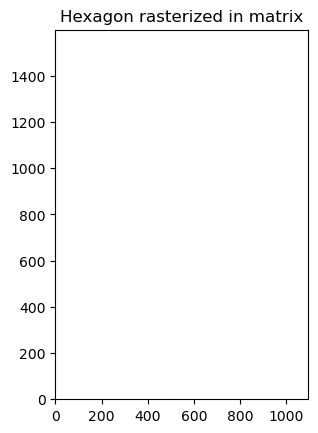

In [9]:

plt.imshow(matrix, origin='lower', cmap='Greys')
plt.title("Hexagon rasterized in matrix")
plt.show()

## Algorithm(Draft)

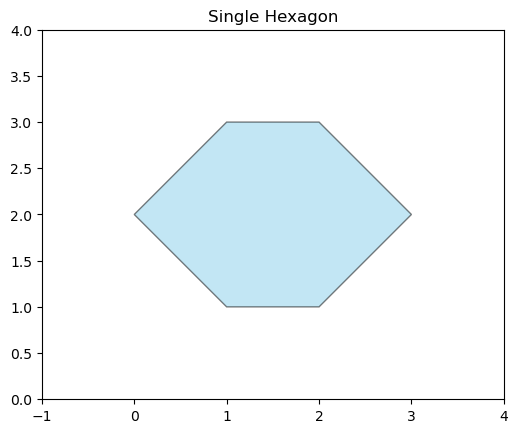

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Example: 2D hexagon vertices
hexagon_vertices = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [2, 3],
    [1, 3],
    [0, 2]
])

# Create the figure
fig, ax = plt.subplots()

# Add polygon patch
hexagon = Polygon(hexagon_vertices, closed=True, facecolor='skyblue', edgecolor='black', alpha=0.5)
ax.add_patch(hexagon)

# Set limits so you can see it
ax.set_xlim(-1, 4)
ax.set_ylim(0, 4)
ax.set_aspect('equal')  # Keep aspect ratio square

plt.title("Single Hexagon")
plt.show()

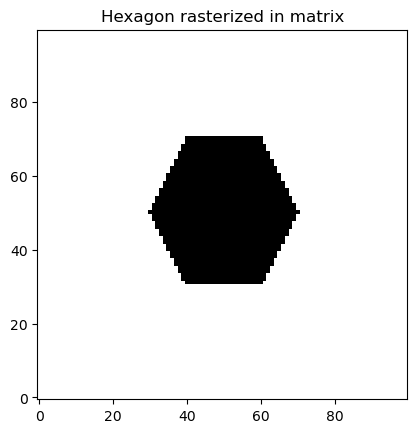

In [12]:
import numpy as np
from matplotlib.path import Path

# Size of the grid
grid_size = 100
matrix = np.zeros((grid_size, grid_size), dtype=int)

# Hexagon vertices (in grid coordinates)
hexagon_vertices = np.array([
    [40, 30],
    [60, 30],
    [70, 50],
    [60, 70],
    [40, 70],
    [30, 50]
])

# Make a Path object
hex_path = Path(hexagon_vertices)

# Generate all points in the grid
xv, yv = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
points = np.vstack((xv.flatten(), yv.flatten())).T

# Check which points are inside the hexagon
mask = hex_path.contains_points(points).reshape(grid_size, grid_size)

# Fill the matrix
matrix[mask] += 1

plt.imshow(matrix, origin='lower', cmap='Greys')
plt.title("Hexagon rasterized in matrix")
plt.show()

## Graphs

### 3D Map

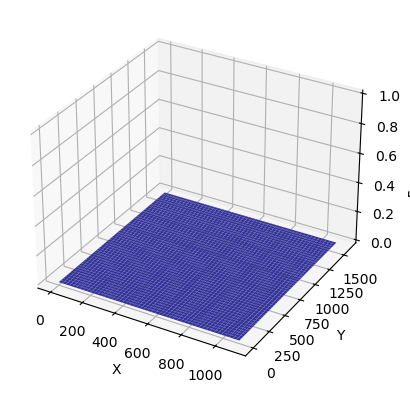

In [7]:
# Create X, Y coordinates
x = np.arange(matrix.shape[1])
y = np.arange(matrix.shape[0])
X, Y = np.meshgrid(x, y)

# Plot

fig, ax = plt.subplots(subplot_kw={'projection':'3d'})

#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, matrix, cmap='terrain')  # 'terrain' colormap looks like mountains
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Frequency")
plt.show()

## 3d render

In [ ]:

grid_size_y, grid_size_x = matrix.shape

# Create x and y coordinate grids
x = np.arange(grid_size_x)
y = np.arange(grid_size_y)
X, Y = np.meshgrid(x, y)  # X: columns, Y: rows

Z = matrix  # z = matrix value

# Create 3D figure
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
ax.plot_surface(X, Y, Z, cmap='viridis')

### Heat map

In [ ]:
plt.imshow(matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')  # adds a color scale
plt.title("Heatmap of Matrix")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()